# Parameter-recovery experiment data

Load the canonical controlled FNN parameter-recovery JSONLs into one tidy DataFrame. Each row is one training epoch; `parameter_trace` contains the learned-versus-true physical parameters recorded at that epoch. These runs use oracle topology and vary one physical scalar at a time.

In [74]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd


REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").is_file():
    raise RuntimeError(f"Expected to run from the repository root, got {REPO_ROOT}")

RESULTS_DIR = (
    REPO_ROOT
    / "derived"
    / "results"
    / "parameter_recovery"
)


FILENAME_PATTERN = re.compile(
    r"^paramrecovery_"
    r"(?P<stage>joint)_"
    r"(?P<dynamic>diffusion|wave|coupled_oscillator)_"
    r"(?P<topology>[^_]+)_"
    r"(?P<parameter>dt|gamma|omega|force_scale|topology)"
    r"init(?P<initial_value>[^_]+)_"
    r"recoverylr(?P<recovery_lr>[^_]+)_"
    r"models(?P<models>\d+)_"
    r"epochs(?P<epochs>\d+)_"
    r"nodes(?P<num_nodes>\d+)_"
    r"episodes(?P<num_episodes>\d+)_"
    r"bins(?P<num_bins>\d+)_"
    r"events(?P<events_per_bin>\d+)_"
    r"dropint(?P<raindrop_interval>\d+)_"
    r"tau(?P<event_threshold>[^_]+)_"
    r"trainroll(?P<rollout_train_steps>\d+)_"
    r"rollhorizon(?P<rollout_horizon>\d+)_"
    r"seed(?P<seed>\d+)\.jsonl$"
)


def decode_numeric_tag(value: str) -> float:
    return float(
        value
        .replace("p", ".")
        .replace("m", "-")
    )


def load_parameter_results(
    results_dir: Path,
) -> pd.DataFrame:

    paths = sorted(
        results_dir.glob("paramrecovery_joint_*.jsonl")
    )

    if not paths:
        raise FileNotFoundError(
            f"No joint parameter-recovery JSONLs found in "
            f"{results_dir}"
        )

    records = []

    for path in paths:

        match = FILENAME_PATTERN.fullmatch(path.name)

        if match is None:
            raise ValueError(
                f"Unexpected parameter-recovery filename: "
                f"{path.name}"
            )

        meta = match.groupdict()

        # Numeric filename metadata
        for key in [
            "models",
            "epochs",
            "num_nodes",
            "num_episodes",
            "num_bins",
            "events_per_bin",
            "raindrop_interval",
            "rollout_train_steps",
            "rollout_horizon",
            "seed",
        ]:
            meta[key] = int(meta[key])

        for key in [
            "initial_value",
            "recovery_lr",
            "event_threshold",
        ]:
            meta[key] = decode_numeric_tag(meta[key])

        meta["source_file"] = path.name

        with path.open(encoding="utf-8") as handle:

            for line_number, line in enumerate(
                handle,
                start=1,
            ):

                if not line.strip():
                    continue

                row = json.loads(line)

                row["source_line"] = line_number
                row.update(meta)

                records.append(row)

    return pd.json_normalize(
        records,
        sep=".",
        max_level=1,
    )


parameter_df = load_parameter_results(
    RESULTS_DIR
)

print(
    f"Loaded {len(parameter_df):,} rows "
    f"from {parameter_df['source_file'].nunique():,} files."
)

parameter_df.head()

Loaded 17,500 rows from 175 files.


,run,seed,epoch,alternating_phase,source_line,stage,dynamic,topology,parameter,initial_value,...,test.learned_omega,test.learned_input_force_scale,recovery.learned_omega,recovery.learned_input_force_scale,parameter_trace.true_omega,parameter_trace.omega_abs_error,test.true_omega,test.omega_abs_error,recovery.true_omega,recovery.omega_abs_error
0,fnn,0,1,None,1,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fnn,0,2,None,2,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fnn,0,3,None,3,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fnn,0,4,None,4,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fnn,0,5,None,5,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
display(
    parameter_df[
        [
            "stage",
            "dynamic",
            "topology",
            "parameter",
            "initial_value",
            "recovery_lr",
            "seed",
            "epoch",
        ]
    ]
    .groupby(
        [
            "dynamic",
            "parameter",
            "initial_value",
            "recovery_lr",
            "seed",
        ],
        as_index=False,
    )
    .agg(
        last_epoch=("epoch", "max"),
        rows=("epoch", "size"),
    )
    .sort_values(
        [
            "dynamic",
            "parameter",
            "initial_value",
            "seed",
        ]
    )
)

,dynamic,parameter,initial_value,recovery_lr,seed,last_epoch,rows
0,diffusion,dt,0.025,0.213,0,100,100
1,diffusion,dt,0.025,0.213,1,100,100
2,diffusion,dt,0.025,0.213,2,100,100
3,diffusion,dt,0.025,0.213,3,100,100
4,diffusion,dt,0.025,0.213,4,100,100
...,...,...,...,...,...,...,...
170,wave,omega,3.200,0.213,0,100,100
171,wave,omega,3.200,0.213,1,100,100
172,wave,omega,3.200,0.213,2,100,100
173,wave,omega,3.200,0.213,3,100,100


In [76]:
TRACE_MAP = {
    "gamma": {
        "learned": "parameter_trace.learned_gamma",
        "true": "parameter_trace.true_gamma",
        "label": r"$\gamma$",
    },
    "dt": {
        "learned": "parameter_trace.learned_dt",
        "true": "parameter_trace.true_dt",
        "label": r"$\Delta t$",
    },
    "force_scale": {
        "learned": "parameter_trace.learned_force_scale",
        "true": "parameter_trace.true_force_scale",
        "label": "Force scale",
    },
    "omega": {
        "learned": "parameter_trace.learned_omega",
        "true": "parameter_trace.true_omega",
        "label": r"$\omega$",
    },
}

joint_traces = parameter_df.copy()

for parameter, cfg in TRACE_MAP.items():
    joint_traces[f"{parameter}_rel"] = (
        joint_traces[cfg["learned"]]
        / joint_traces[cfg["true"]]
    )

joint_traces.head()

,run,seed,epoch,alternating_phase,source_line,stage,dynamic,topology,parameter,initial_value,...,parameter_trace.true_omega,parameter_trace.omega_abs_error,test.true_omega,test.omega_abs_error,recovery.true_omega,recovery.omega_abs_error,gamma_rel,dt_rel,force_scale_rel,omega_rel
0,fnn,0,1,None,1,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,0.897083,0.246072,1.098085,NaN
1,fnn,0,2,None,2,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,0.800627,0.241483,1.207469,NaN
2,fnn,0,3,None,3,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,0.715637,0.236574,1.325391,NaN
3,fnn,0,4,None,4,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,0.641956,0.231430,1.449756,NaN
4,fnn,0,5,None,5,joint,diffusion,ring,dt,0.025,...,NaN,NaN,NaN,NaN,NaN,NaN,0.578320,0.226112,1.579257,NaN


In [77]:
display(
    joint_traces.groupby(
        ["dynamic", "parameter", "initial_value", "seed"],
        as_index=False,
    ).agg(
        epochs=("epoch", "nunique"),
        gamma=("gamma_rel", "count"),
        dt=("dt_rel", "count"),
        force_scale=("force_scale_rel", "count"),
        omega=("omega_rel", "count"),
    )
)

,dynamic,parameter,initial_value,seed,epochs,gamma,dt,force_scale,omega
0,diffusion,dt,0.025,0,100,100,100,100,0
1,diffusion,dt,0.025,1,100,100,100,100,0
2,diffusion,dt,0.025,2,100,100,100,100,0
3,diffusion,dt,0.025,3,100,100,100,100,0
4,diffusion,dt,0.025,4,100,100,100,100,0
...,...,...,...,...,...,...,...,...,...
170,wave,omega,3.200,0,100,100,100,100,100
171,wave,omega,3.200,1,100,100,100,100,100
172,wave,omega,3.200,2,100,100,100,100,100
173,wave,omega,3.200,3,100,100,100,100,100


In [78]:
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
import numpy as np


def add_fading_path(
    ax,
    x,
    y,
    *,
    color,
    linewidth=1.8,
    alpha_start=0.12,
    alpha_end=0.95,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (y > 0)
    )

    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return

    # Convert hex/name/tuple colors safely to RGBA.
    base_rgba = to_rgba(color)

    points = np.column_stack([x, y]).reshape(-1, 1, 2)

    segments = np.concatenate(
        [points[:-1], points[1:]],
        axis=1,
    )

    alphas = np.linspace(
        alpha_start,
        alpha_end,
        len(segments),
    )

    segment_colors = [
        (
            base_rgba[0],
            base_rgba[1],
            base_rgba[2],
            alpha,
        )
        for alpha in alphas
    ]

    collection = LineCollection(
        segments,
        colors=segment_colors,
        linewidths=linewidth,
        zorder=2,
    )

    ax.add_collection(collection)

    # Starting point: open circle
    ax.scatter(
        x[0],
        y[0],
        s=28,
        facecolor="white",
        edgecolor=color,
        linewidth=1.0,
        zorder=4,
    )

    # Final point: filled circle
    ax.scatter(
        x[-1],
        y[-1],
        s=28,
        facecolor=color,
        edgecolor=color,
        linewidth=0.8,
        zorder=4,
    )

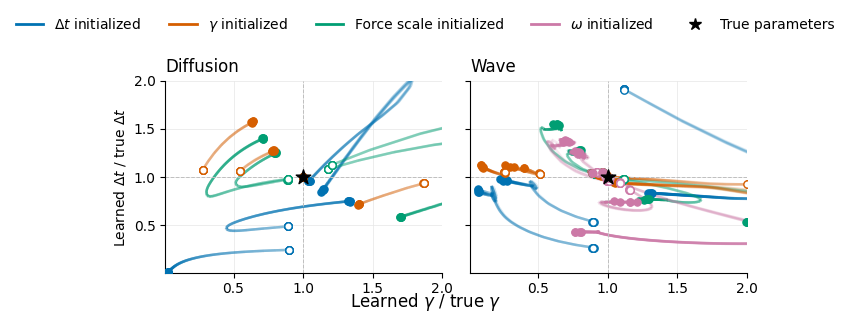

In [79]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(6.5, 3.1),
    sharex=True,
    sharey=True,
)

INIT_COLORS = {
    "dt": "#0072B2",
    "gamma": "#D55E00",
    "force_scale": "#009E73",
    "omega": "#CC79A7",
}

for ax, dynamic in zip(axes, ["diffusion", "wave"]):

    sub = joint_traces[
        joint_traces["dynamic"].eq(dynamic)
    ].copy()

    for source_file, g in sub.groupby("source_file"):
        g = g.sort_values("epoch")

        init_parameter = g["parameter"].iloc[0]
        color = INIT_COLORS.get(init_parameter, "0.4")

        add_fading_path(
            ax,
            g["gamma_rel"],
            g["dt_rel"],
            color=color,
        )

    ax.scatter(
        1.0, 1.0,
        marker="*",
        s=120,
        color="black",
        zorder=10,
    )

    ax.axvline(1.0, color="0.75", linestyle="--", linewidth=0.7)
    ax.axhline(1.0, color="0.75", linestyle="--", linewidth=0.7)

    #ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlim(0.01, 2.0)
    ax.set_ylim(0.01, 2.0)

    ax.set_title(dynamic.title(), loc="left")

    ax.grid(color="0.90", linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(
    r"Learned $\Delta t$ / true $\Delta t$"
)

fig.supxlabel(
    r"Learned $\gamma$ / true $\gamma$",
    y=0.03,
)

legend_handles = [
    Line2D([0], [0], color=color, lw=2, label=label)
    for label, color in [
        (r"$\Delta t$ initialized", INIT_COLORS["dt"]),
        (r"$\gamma$ initialized", INIT_COLORS["gamma"]),
        ("Force scale initialized", INIT_COLORS["force_scale"]),
        (r"$\omega$ initialized", INIT_COLORS["omega"]),
    ]
]

legend_handles.append(
    Line2D(
        [0], [0],
        marker="*",
        color="black",
        linewidth=0,
        markersize=9,
        label="True parameters",
    )
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=5,
    frameon=False,
)

fig.subplots_adjust(
    left=0.10,
    right=0.995,
    bottom=0.16,
    top=0.78,
    wspace=0.10,
)

plt.show()

In [80]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PARAM_COLS = {
    "dt": "dt_rel",
    "gamma": "gamma_rel",
    "force": "force_scale_rel",
    "omega": "omega_rel",
}

PARAM_LABELS = {
    "dt": r"$\Delta t / \Delta t^\star$",
    "gamma": r"$\gamma / \gamma^\star$",
    "force": r"Force / Force$^\star$",
    "omega": r"$\omega / \omega^\star$",
}

INIT_COLORS = {
    "dt": "#0072B2",
    "gamma": "#D55E00",
    "force_scale": "#009E73",
    "omega": "#CC79A7",
}


def plot_parameter_matrix(
    df,
    params,
    *,
    dynamic,
    figsize=(6.5, 6.5),
):
    sub = df[df["dynamic"] == dynamic].copy()

    n = len(params)

    fig, axes = plt.subplots(
        n,
        n,
        figsize=figsize,
        sharex="col",
        sharey="row",
    )

    for row_idx, y_param in enumerate(params):
        for col_idx, x_param in enumerate(params):
            ax = axes[row_idx, col_idx]

            # Upper triangle: blank
            if row_idx < col_idx:
                ax.axis("off")
                continue

            # Diagonal: parameter label
            if row_idx == col_idx:
                ax.text(
                    0.5, 0.5,
                    PARAM_LABELS[y_param],
                    ha="center",
                    va="center",
                    fontsize=9,
                    transform=ax.transAxes,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                continue

            # Lower triangle: actual pairwise trajectory panel
            x_col = PARAM_COLS[x_param]
            y_col = PARAM_COLS[y_param]

            for source_file, g in sub.groupby("source_file"):
                g = g.sort_values("epoch")

                init_parameter = g["parameter"].iloc[0]
                color = INIT_COLORS.get(init_parameter, "0.5")

                add_fading_path(
                    ax,
                    g[x_col],
                    g[y_col],
                    color=color,
                    linewidth=1.6,
                )

            ax.scatter(
                1.0, 1.0,
                marker="*",
                s=80,
                color="black",
                zorder=10,
            )

            ax.axvline(
                1.0,
                color="0.75",
                linestyle="--",
                linewidth=0.7,
                zorder=0,
            )
            ax.axhline(
                1.0,
                color="0.75",
                linestyle="--",
                linewidth=0.7,
                zorder=0,
            )

            #ax.set_xscale("log")
            #ax.set_yscale("log")
            ax.set_xlim(0.01, 2.0)
            ax.set_ylim(0.01, 2.0)

            ax.grid(color="0.92", linewidth=0.5)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(labelsize=7, length=2.5, width=0.6)

            if row_idx == n - 1:
                ax.set_xlabel(PARAM_LABELS[x_param], fontsize=8)

            if col_idx == 0:
                ax.set_ylabel(PARAM_LABELS[y_param], fontsize=8)

    legend_handles = [
        Line2D([0], [0], color=INIT_COLORS["dt"], lw=2, label=r"$\Delta t$ initialized"),
        Line2D([0], [0], color=INIT_COLORS["gamma"], lw=2, label=r"$\gamma$ initialized"),
        Line2D([0], [0], color=INIT_COLORS["force_scale"], lw=2, label="Force initialized"),
    ]

    if "omega" in params:
        legend_handles.append(
            Line2D([0], [0], color=INIT_COLORS["omega"], lw=2, label=r"$\omega$ initialized")
        )

    legend_handles.append(
        Line2D([0], [0], marker="*", color="black", lw=0, markersize=8, label="True parameters")
    )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(len(legend_handles), 5),
        frameon=False,
        fontsize=8,
    )

    fig.suptitle(dynamic.title(), y=0.98, fontsize=10)

    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        bottom=0.08,
        top=0.92,
        wspace=0.08,
        hspace=0.08,
    )

    return fig, axes

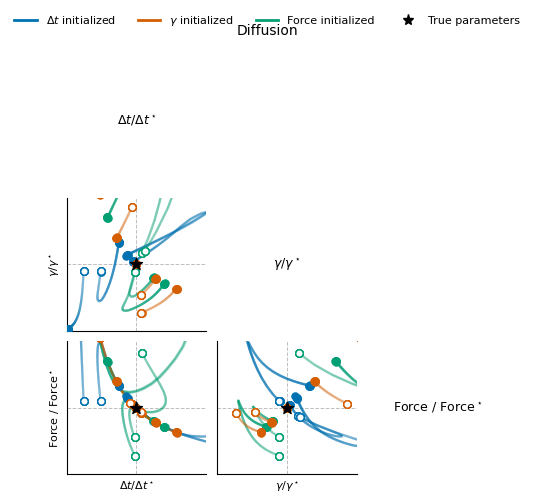

In [81]:
fig, axes = plot_parameter_matrix(
    joint_traces,
    params=["dt", "gamma", "force"],
    dynamic="diffusion",
    figsize=(5.0, 5.0),
)
plt.show()

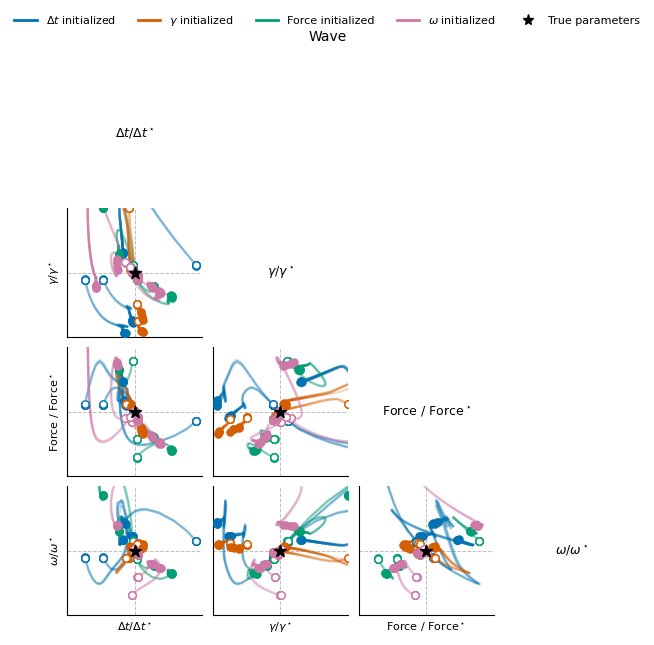

In [82]:
fig, axes = plot_parameter_matrix(
    joint_traces,
    params=["dt", "gamma", "force", "omega"],
    dynamic="wave",
    figsize=(6.5, 6.5),
)
plt.show()